In [1]:
from google.colab import files
uploaded = files.upload()

Saving kaggle.json to kaggle.json


In [2]:
!pip install -q kaggle

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

print("Kaggle API configured")

Kaggle API configured


In [3]:
!rm -f /content/*.zip

!kaggle datasets download -d shoybhasan/camus-human-heart-data -p /content --force

Dataset URL: https://www.kaggle.com/datasets/shoybhasan/camus-human-heart-data
License(s): other
100% 3.49G/3.50G [00:32<00:00, 235MB/s]
100% 3.50G/3.50G [00:32<00:00, 115MB/s]


In [4]:
!rm -rf /content/camus_data
!mkdir -p /content/camus_data

!unzip -q /content/camus-human-heart-data.zip -d /content/camus_data

In [5]:
!rm -rf /content/camus_full
!mkdir -p /content/camus_full

!unzip -q /content/camus_data/download -d /content/camus_full

In [6]:
import os

print(os.listdir("/content/camus_full")[:10])

root_dir = "/content/camus_full/database_nifti"

print("Patient folders:", len(os.listdir(root_dir)))
print(os.listdir(root_dir)[:5])

['database_nifti']
Patient folders: 500
['patient0314', 'patient0220', 'patient0016', 'patient0453', 'patient0429']


In [8]:
!pip -q install nibabel segmentation-models-pytorch albumentations torchmetrics medpy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 156.3/156.3 kB 5.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 29.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 MB 16.3 MB/s eta 0:00:00


In [10]:
import os, glob, random
import numpy as np
import pandas as pd
import nibabel as nib
import cv2
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split, WeightedRandomSampler

import albumentations as A
from albumentations.pytorch import ToTensorV2

import segmentation_models_pytorch as smp
from medpy.metric.binary import hd95

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# Tesla T4 safe defaults
IMAGE_SIZE = 256
BATCH_SIZE = 4
LR = 1e-4
NUM_CLASSES = 4  # 0=BG, 1=LV, 2=MYO, 3=LA
EPOCHS = 3       # change to 20 for final dissertation runs

os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
cv2.setNumThreads(0)
torch.set_num_threads(1)
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True
print("Thread + cuDNN safe settings applied")

Device: cuda
Thread + cuDNN safe settings applied


In [11]:
def get_patient_dirs(root_dir):
    return sorted([
        d for d in os.listdir(root_dir)
        if d.startswith("patient") and os.path.isdir(os.path.join(root_dir, d))
    ])

def get_image_mask_pairs(root_dir):
    images, masks, meta = [], [], []
    patient_dirs = get_patient_dirs(root_dir)

    for p in patient_dirs:
        p_path = os.path.join(root_dir, p)
        for view in ["2CH", "4CH"]:
            for phase in ["ED", "ES"]:
                img = glob.glob(os.path.join(p_path, f"*_{view}_{phase}.nii.gz"))
                gt  = glob.glob(os.path.join(p_path, f"*_{view}_{phase}_gt.nii.gz"))
                if img and gt:
                    images.append(img[0])
                    masks.append(gt[0])
                    meta.append({"patient": p, "view": view, "phase": phase})

    return images, masks, pd.DataFrame(meta)

images, masks, meta_df = get_image_mask_pairs(root_dir)
print("Total image-mask pairs:", len(images))
print("Example image:", images[0])
print("Example mask :", masks[0])
display(meta_df.head())

Total image-mask pairs: 2000
Example image: /content/camus_full/database_nifti/patient0001/patient0001_2CH_ED.nii.gz
Example mask : /content/camus_full/database_nifti/patient0001/patient0001_2CH_ED_gt.nii.gz


,patient,view,phase
0,patient0001,2CH,ED
1,patient0001,2CH,ES
2,patient0001,4CH,ED
3,patient0001,4CH,ES
4,patient0002,2CH,ED


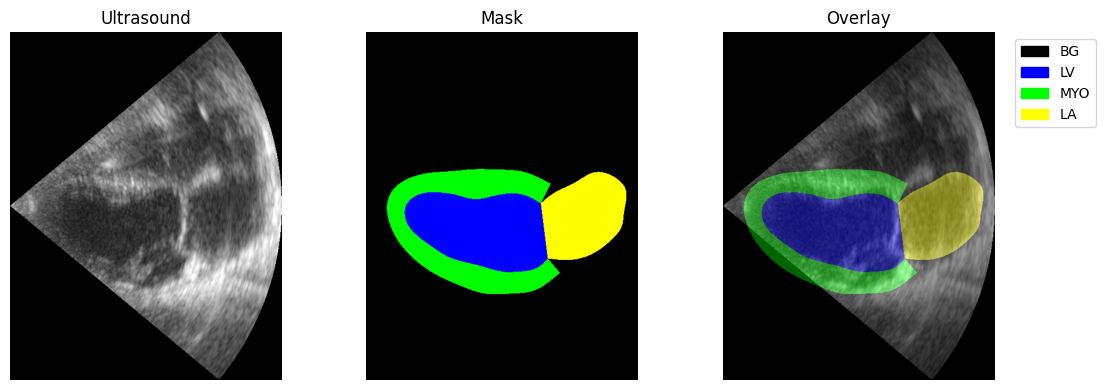

Sample file: patient0356_4CH_ES.nii.gz
Unique labels: [0. 1. 2. 3.]


In [15]:
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches

LABEL_MAP = {0:"BG", 1:"LV", 2:"MYO", 3:"LA"}
colors = [
    (0,0,0),   # BG - black
    (0,0,1),   # LV - blue
    (0,1,0),   # MYO - green
    (1,1,0)    # LA - yellow
]
cmap = ListedColormap(colors)

idx = random.randint(0, len(images)-1)
img = nib.load(images[idx]).get_fdata()
msk = nib.load(masks[idx]).get_fdata()

if img.ndim == 3: img = img[:,:,0]
if msk.ndim == 3: msk = msk[:,:,0]

plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.title("Ultrasound"); plt.imshow(img, cmap="gray"); plt.axis("off")
plt.subplot(1,3,2); plt.title("Mask"); plt.imshow(msk, cmap=cmap, vmin=0, vmax=3); plt.axis("off")
plt.subplot(1,3,3); plt.title("Overlay"); plt.imshow(img, cmap="gray"); plt.imshow(msk, cmap=cmap, alpha=0.4, vmin=0, vmax=3); plt.axis("off")

legend_patches = [mpatches.Patch(color=colors[i], label=LABEL_MAP[i]) for i in LABEL_MAP]
plt.legend(handles=legend_patches, bbox_to_anchor=(1.05,1), loc="upper left")

plt.tight_layout(); plt.show()

print("Sample file:", os.path.basename(images[idx]))
print("Unique labels:", np.unique(msk))

In [16]:
class CamusNiftiDataset(Dataset):
    def __init__(self, image_paths, mask_paths, transform=None, size=256):
        self.image_paths = image_paths
        self.mask_paths = mask_paths
        self.transform = transform
        self.size = size

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = np.asanyarray(nib.load(self.image_paths[idx]).dataobj)
        msk = np.asanyarray(nib.load(self.mask_paths[idx]).dataobj)

        if img.ndim == 3:
            img = img[:, :, 0]
        if msk.ndim == 3:
            msk = msk[:, :, 0]

        img = cv2.resize(img, (self.size, self.size), interpolation=cv2.INTER_LINEAR)
        msk = cv2.resize(msk, (self.size, self.size), interpolation=cv2.INTER_NEAREST)

        img = (img - img.min()) / (img.max() - img.min() + 1e-8)
        msk = msk.astype(np.int64)  # keep {0,1,2,3}

        if self.transform:
            out = self.transform(image=img.astype(np.float32), mask=msk)
            img = out["image"]
            msk = out["mask"].long()

        return img.float(), msk


transform = A.Compose([
    A.Normalize(mean=(0.5,), std=(0.5,)),
    ToTensorV2()
])

dataset = CamusNiftiDataset(images, masks, transform=transform, size=IMAGE_SIZE)

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_ds, val_ds = random_split(dataset, [train_size, val_size])

print("Train:", len(train_ds), "Val:", len(val_ds))

Train: 1600 Val: 400


In [17]:
from collections import Counter
from torch.utils.data import WeightedRandomSampler

# ---------- YOUR ORIGINAL WEIGHTED SAMPLER (KEEP) ----------
def compute_sample_weights(seg_subset, eps=1e-6):
    weights = []
    for i in range(len(seg_subset)):
        _, mask = seg_subset[i]
        m = mask.detach().cpu().numpy()

        fg_ratio = (m != 0).mean()
        has_la  = (m == 3).any()
        has_myo = (m == 2).any()
        has_lv  = (m == 1).any()

        w = 1.0 + 5.0 * fg_ratio
        if has_la:  w += 2.0
        if has_myo: w += 1.0
        if has_lv:  w += 0.5

        weights.append(w + eps)

    return torch.DoubleTensor(weights)

# ---------- BALANCED SAMPLER (NEW) ----------
# Group rule: LA > MYO > LV > BG-only
def assign_group(mask_np):
    if (mask_np == 3).any(): return 3
    if (mask_np == 2).any(): return 2
    if (mask_np == 1).any(): return 1
    return 0

def compute_balanced_group_weights(seg_subset):
    groups = []
    for i in range(len(seg_subset)):
        _, mask = seg_subset[i]
        m = mask.detach().cpu().numpy()
        groups.append(assign_group(m))

    group_counts = Counter(groups)
    inv = {g: 1.0 / group_counts[g] for g in group_counts}
    weights = [inv[g] for g in groups]
    return torch.DoubleTensor(weights), group_counts

def make_train_loader(train_ds, sampler_type="weighted"):
    if sampler_type == "random":
        return DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)

    if sampler_type == "weighted":
        w = compute_sample_weights(train_ds)
        sampler = WeightedRandomSampler(weights=w, num_samples=len(w), replacement=True)
        return DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler, shuffle=False, num_workers=0)

    if sampler_type == "balanced":
        w, group_counts = compute_balanced_group_weights(train_ds)
        print("Balanced sampler group counts:", group_counts, "(0=BG-only,1=LV,2=MYO,3=LA)")
        sampler = WeightedRandomSampler(weights=w, num_samples=len(w), replacement=True)
        return DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler, shuffle=False, num_workers=0)

    raise ValueError("sampler_type must be: random | weighted | balanced")

val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

train_loader_random  = make_train_loader(train_ds, "random")
train_loader_weighted = make_train_loader(train_ds, "weighted")
train_loader_balanced = make_train_loader(train_ds, "balanced")

print("Dataloaders ready:", len(train_ds), "train /", len(val_ds), "val")

Balanced sampler group counts: Counter({3: 1600}) (0=BG-only,1=LV,2=MYO,3=LA)
Dataloaders ready: 1600 train / 400 val


In [19]:
from collections import Counter
import pandas as pd
import numpy as np

# -----------------------------
# Pixel share analysis
# -----------------------------
def compute_pixel_share(loader, max_batches=20):

    cnt = Counter()

    for b, (_, y) in enumerate(loader):

        y = y.numpy()

        for cls in [0,1,2,3]:
            cnt[cls] += int((y == cls).sum())

        if b >= max_batches:
            break

    total = sum(cnt.values())

    return {
        "BG": cnt[0]/total,
        "LV": cnt[1]/total,
        "MYO": cnt[2]/total,
        "LA": cnt[3]/total
    }


# -----------------------------
# Image presence analysis (NEW)
# -----------------------------
def compute_image_presence(loader, max_batches=20):

    cnt = Counter()
    total_images = 0

    for b, (_, y) in enumerate(loader):

        y = y.numpy()

        for i in range(y.shape[0]):

            mask = y[i]

            for cls in [1,2,3]:
                if (mask == cls).any():
                    cnt[cls] += 1

            total_images += 1

        if b >= max_batches:
            break

    return {
        "LV_presence": cnt[1]/total_images,
        "MYO_presence": cnt[2]/total_images,
        "LA_presence": cnt[3]/total_images
    }


# -----------------------------
# Compute results
# -----------------------------
pixel_random   = compute_pixel_share(train_loader_random)
pixel_weighted = compute_pixel_share(train_loader_weighted)
pixel_balanced = compute_pixel_share(train_loader_balanced)

presence_random   = compute_image_presence(train_loader_random)
presence_weighted = compute_image_presence(train_loader_weighted)
presence_balanced = compute_image_presence(train_loader_balanced)


# -----------------------------
# Tables
# -----------------------------
pixel_table = pd.DataFrame({
    "Random": pixel_random,
    "Weighted": pixel_weighted,
    "Balanced": pixel_balanced
})

presence_table = pd.DataFrame({
    "Random": presence_random,
    "Weighted": presence_weighted,
    "Balanced": presence_balanced
})


print("===== Pixel Share (sampled batches) =====")
display(pixel_table)

print("\n===== Image Presence (sampled batches) =====")
display(presence_table)

===== Pixel Share (sampled batches) =====


,Random,Weighted,Balanced
BG,0.754240,0.755312,0.754834
LV,0.096216,0.089688,0.089698
MYO,0.101754,0.102448,0.103419
LA,0.047791,0.052553,0.052048



===== Image Presence (sampled batches) =====


,Random,Weighted,Balanced
LV_presence,1.0,1.0,1.0
MYO_presence,1.0,1.0,1.0
LA_presence,1.0,1.0,1.0


In [38]:
# Choose the sampler you want to train with:
# "random" | "weighted" | "balanced"
SAMPLER_CHOICE = "balanced"   # change to "balanced" for comparison

train_loader = make_train_loader(train_ds, SAMPLER_CHOICE)
print(" Training with sampler:", SAMPLER_CHOICE)

Balanced sampler group counts: Counter({3: 1600}) (0=BG-only,1=LV,2=MYO,3=LA)
 Training with sampler: balanced


In [39]:
results = {}
torch.cuda.empty_cache()

In [21]:
def model_unet():     # Paper 1 + Paper 5
    return smp.Unet("resnet34", encoder_weights="imagenet", in_channels=1, classes=NUM_CLASSES).to(device)

def model_deeplab():  # Paper 2
    return smp.DeepLabV3("resnet34", encoder_weights="imagenet", in_channels=1, classes=NUM_CLASSES).to(device)

def model_resunet():  # Paper 4 (stronger encoder)
    return smp.Unet("resnet50", encoder_weights="imagenet", in_channels=1, classes=NUM_CLASSES).to(device)

In [24]:
# Loss functions (same as old but CE+Dice uses weighted CE inside)
def soft_dice_loss(logits, targets, num_classes=NUM_CLASSES, eps=1e-6):
    probs = torch.softmax(logits, dim=1)
    targets_oh = torch.nn.functional.one_hot(targets, num_classes).permute(0,3,1,2).float()
    dims = (0,2,3)
    intersection = torch.sum(probs * targets_oh, dims)
    union = torch.sum(probs + targets_oh, dims)
    dice = (2 * intersection + eps) / (union + eps)
    return 1 - dice[1:].mean()  # ignore background

class CEPlusDice(nn.Module):
    def __init__(self, ce_weight=0.5, ce_loss=None):
        super().__init__()
        self.ce_weight = ce_weight
        self.ce = ce_loss if ce_loss is not None else nn.CrossEntropyLoss()

    def forward(self, logits, targets):
        return self.ce_weight * self.ce(logits, targets) + (1 - self.ce_weight) * soft_dice_loss(logits, targets)

class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, reduction="mean"):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction
        self.ce = nn.CrossEntropyLoss(reduction="none")

    def forward(self, logits, targets):
        ce_loss = self.ce(logits, targets)
        pt = torch.exp(-ce_loss)
        focal = (1 - pt) ** self.gamma * ce_loss
        if self.alpha is not None:
            at = self.alpha.gather(0, targets.view(-1)).view_as(targets)
            focal = at * focal
        return focal.mean() if self.reduction == "mean" else focal.sum()

# Professor asked to vary these later in a table
class_weights = torch.tensor([0.2, 1.0, 1.0, 1.3], device=device)

ce_weighted = nn.CrossEntropyLoss(weight=class_weights)
focal_loss_fn = FocalLoss(alpha=class_weights, gamma=2.0)

print("Losses ready. Class weights:", class_weights.detach().cpu().numpy())

Losses ready. Class weights: [0.2 1.  1.  1.3]


In [25]:
def dice_iou_for_class(pred, true, cls, eps=1e-8):
    pred_c = (pred == cls)
    true_c = (true == cls)
    inter = (pred_c & true_c).sum()
    dice = (2*inter) / (pred_c.sum() + true_c.sum() + eps)
    iou  = inter / (pred_c.sum() + true_c.sum() - inter + eps)
    return float(dice), float(iou)

def evaluate_fast(model, loader):
    model.eval()
    dices = {0: [], 1: [], 2: [], 3: []}
    ious  = {0: [], 1: [], 2: [], 3: []}

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            y = y.to(device)
            logits = model(x)
            pred = torch.argmax(logits, dim=1).cpu().numpy()
            true = y.cpu().numpy()

            for b in range(pred.shape[0]):
                for cls in [0,1,2,3]:
                    d, i = dice_iou_for_class(pred[b], true[b], cls)
                    dices[cls].append(d)
                    ious[cls].append(i)

    return {
        "Dice_BG": np.mean(dices[0]), "Dice_LV": np.mean(dices[1]),
        "Dice_MYO": np.mean(dices[2]), "Dice_LA": np.mean(dices[3]),
        "IoU_BG": np.mean(ious[0]), "IoU_LV": np.mean(ious[1]),
        "IoU_MYO": np.mean(ious[2]), "IoU_LA": np.mean(ious[3]),
    }

def evaluate_hd95_only(model, loader):
    model.eval()
    hds = {1: [], 2: [], 3: []}
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            y = y.to(device)
            logits = model(x)
            pred = torch.argmax(logits, dim=1).cpu().numpy()
            true = y.cpu().numpy()

            for b in range(pred.shape[0]):
                for cls in [1,2,3]:
                    try:
                        if (pred[b] == cls).any() and (true[b] == cls).any():
                            hds[cls].append(
                                hd95((pred[b] == cls).astype(np.uint8),
                                     (true[b] == cls).astype(np.uint8))
                            )
                    except:
                        pass

    return {
        "HD95_LV": np.mean(hds[1]) if len(hds[1]) else np.nan,
        "HD95_MYO": np.mean(hds[2]) if len(hds[2]) else np.nan,
        "HD95_LA": np.mean(hds[3]) if len(hds[3]) else np.nan,
    }

In [26]:
import copy

def train_model_best(model, loss_fn, epochs=3, lr=LR, log_every=100):
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    best_state = None
    best_score = -1.0

    for ep in range(1, epochs+1):
        model.train()
        total_loss = 0.0
        print(f"\n>>> Epoch {ep}/{epochs} started")

        for bi, (x, y) in enumerate(train_loader):
            x = x.to(device)
            y = y.to(device)

            logits = model(x)
            loss = loss_fn(logits, y)

            opt.zero_grad()
            loss.backward()
            opt.step()

            total_loss += loss.item()
            if (bi + 1) % log_every == 0:
                print(f" batch {bi+1}/{len(train_loader)} | loss {total_loss/(bi+1):.4f}")

        metrics = evaluate_fast(model, val_loader)
        score = float(np.mean([metrics["Dice_LV"], metrics["Dice_MYO"], metrics["Dice_LA"]]))

        print(
            f">>> Epoch {ep} finished | Loss {total_loss/len(train_loader):.4f} | "
            f"Dice(LV) {metrics['Dice_LV']:.4f} | Dice(MYO) {metrics['Dice_MYO']:.4f} | "
            f"Dice(LA) {metrics['Dice_LA']:.4f} | AvgDice {score:.4f}"
        )

        if score > best_score:
            best_score = score
            best_state = copy.deepcopy(model.state_dict())
            print(f" Best model saved (AvgDice {best_score:.4f})")

    model.load_state_dict(best_state)
    print(f"\n>>> Restored BEST epoch model | Best AvgDice: {best_score:.4f}")
    return model

In [27]:
results = {}

def run_one(name, model_fn, loss_fn):

    print("\n====================")
    print("Starting:", name)
    print("====================")

    m = model_fn()

    m = train_model_best(m, loss_fn, epochs=EPOCHS, log_every=10)

    res = evaluate_fast(m, val_loader)

    res.update(evaluate_hd95_only(m, val_loader))

    results[name] = res

    return m

In [29]:
print(EPOCHS)

3


In [40]:
m1 = run_one("Paper1_UNet", model_unet, ce_weighted)

m2 = run_one("Paper2_DeepLabV3", model_deeplab, ce_weighted)

m3 = run_one("Paper3_UNet_CE+Dice", model_unet, CEPlusDice(0.5, ce_loss=ce_weighted))

m4 = run_one("Paper4_ResUNet", model_resunet, ce_weighted)

m5 = run_one("Paper5_UNet_Baseline", model_unet, ce_weighted)


Starting: Paper1_UNet

>>> Epoch 1/3 started
 batch 10/400 | loss 1.2225
 batch 20/400 | loss 1.0652
 batch 30/400 | loss 0.9692
 batch 40/400 | loss 0.9071
 batch 50/400 | loss 0.8519
 batch 60/400 | loss 0.8104
 batch 70/400 | loss 0.7755
 batch 80/400 | loss 0.7444
 batch 90/400 | loss 0.7127
 batch 100/400 | loss 0.6823
 batch 110/400 | loss 0.6587
 batch 120/400 | loss 0.6342
 batch 130/400 | loss 0.6148
 batch 140/400 | loss 0.5985
 batch 150/400 | loss 0.5816
 batch 160/400 | loss 0.5677
 batch 170/400 | loss 0.5538
 batch 180/400 | loss 0.5400
 batch 190/400 | loss 0.5285
 batch 200/400 | loss 0.5179
 batch 210/400 | loss 0.5061
 batch 220/400 | loss 0.4961
 batch 230/400 | loss 0.4864
 batch 240/400 | loss 0.4774
 batch 250/400 | loss 0.4690
 batch 260/400 | loss 0.4606
 batch 270/400 | loss 0.4531
 batch 280/400 | loss 0.4455
 batch 290/400 | loss 0.4382
 batch 300/400 | loss 0.4321
 batch 310/400 | loss 0.4251
 batch 320/400 | loss 0.4183
 batch 330/400 | loss 0.4124
 batch

In [41]:
df = pd.DataFrame(results).T

df["Mean_Dice"] = df[["Dice_LV","Dice_MYO","Dice_LA"]].mean(axis=1)
df["Mean_HD95"] = df[["HD95_LV","HD95_MYO","HD95_LA"]].mean(axis=1)

df = df.sort_values("Mean_Dice", ascending=False)

df

,Dice_BG,Dice_LV,Dice_MYO,Dice_LA,IoU_BG,IoU_LV,IoU_MYO,IoU_LA,HD95_LV,HD95_MYO,HD95_LA,Mean_Dice,Mean_HD95
Paper3_UNet_CE+Dice,0.976617,0.919684,0.835167,0.863247,0.954583,0.854742,0.721094,0.773603,7.166854,8.392690,9.553928,0.872700,8.371158
Paper5_UNet_Baseline,0.976190,0.919605,0.825496,0.865820,0.953648,0.855426,0.706910,0.776035,6.853599,8.590002,9.865624,0.870307,8.436408
Paper1_UNet,0.969523,0.918228,0.804535,0.844065,0.941122,0.852891,0.677940,0.744068,7.213452,9.988678,11.862619,0.855609,9.688250
Paper2_DeepLabV3,0.968797,0.906351,0.792074,0.863163,0.939890,0.832166,0.660403,0.770839,7.358640,11.107168,9.601173,0.853863,9.355660
Paper4_ResUNet,0.973374,0.909038,0.820102,0.815654,0.948295,0.837449,0.699337,0.707567,7.789557,8.572390,13.028517,0.848265,9.796821


In [42]:
df.to_csv("results_balanced_no_focal.csv")
print("Saved: results_balanced_no_focal.csv")

Saved: results_balanced_no_focal.csv


In [34]:
df.to_csv("results_weighted_no_focal.csv")
print("Saved: results_weighted_no_focal.csv")

Saved: results_weighted_no_focal.csv


In [43]:
results = {}
torch.cuda.empty_cache()

In [44]:
m1_f = run_one("Paper1_UNet_Focal", model_unet, focal_loss_fn)
m2_f = run_one("Paper2_DeepLabV3_Focal", model_deeplab, focal_loss_fn)
m3_f = run_one("Paper3_UNet_FocalReplace", model_unet, focal_loss_fn)
m4_f = run_one("Paper4_ResUNet_Focal", model_resunet, focal_loss_fn)
m5_f = run_one("Paper5_UNet_Baseline_Focal", model_unet, focal_loss_fn)


Starting: Paper1_UNet_Focal

>>> Epoch 1/3 started
 batch 10/400 | loss 0.2675
 batch 20/400 | loss 0.2206
 batch 30/400 | loss 0.1925
 batch 40/400 | loss 0.1756
 batch 50/400 | loss 0.1632
 batch 60/400 | loss 0.1528
 batch 70/400 | loss 0.1436
 batch 80/400 | loss 0.1375
 batch 90/400 | loss 0.1314
 batch 100/400 | loss 0.1266
 batch 110/400 | loss 0.1212
 batch 120/400 | loss 0.1169
 batch 130/400 | loss 0.1118
 batch 140/400 | loss 0.1086
 batch 150/400 | loss 0.1048
 batch 160/400 | loss 0.1012
 batch 170/400 | loss 0.0981
 batch 180/400 | loss 0.0955
 batch 190/400 | loss 0.0930
 batch 200/400 | loss 0.0901
 batch 210/400 | loss 0.0880
 batch 220/400 | loss 0.0859
 batch 230/400 | loss 0.0841
 batch 240/400 | loss 0.0821
 batch 250/400 | loss 0.0804
 batch 260/400 | loss 0.0786
 batch 270/400 | loss 0.0770
 batch 280/400 | loss 0.0754
 batch 290/400 | loss 0.0739
 batch 300/400 | loss 0.0725
 batch 310/400 | loss 0.0711
 batch 320/400 | loss 0.0698
 batch 330/400 | loss 0.0686


In [45]:
df_bal_focal = pd.DataFrame(results).T

df_bal_focal["Mean_Dice"] = df_bal_focal[["Dice_LV","Dice_MYO","Dice_LA"]].mean(axis=1)
df_bal_focal["Mean_HD95"] = df_bal_focal[["HD95_LV","HD95_MYO","HD95_LA"]].mean(axis=1)

df_bal_focal = df_bal_focal.sort_values("Mean_Dice", ascending=False)
display(df_bal_focal)

,Dice_BG,Dice_LV,Dice_MYO,Dice_LA,IoU_BG,IoU_LV,IoU_MYO,IoU_LA,HD95_LV,HD95_MYO,HD95_LA,Mean_Dice,Mean_HD95
Paper4_ResUNet_Focal,0.973480,0.919021,0.828657,0.842175,0.948491,0.854450,0.710961,0.738106,6.770967,8.731614,12.331760,0.863284,9.278114
Paper5_UNet_Baseline_Focal,0.977314,0.887146,0.825946,0.838142,0.955768,0.801218,0.707187,0.731505,8.965071,9.010090,11.836306,0.850411,9.937156
Paper3_UNet_FocalReplace,0.966011,0.913268,0.783924,0.830810,0.934498,0.844293,0.649098,0.723293,7.241465,10.784117,15.292813,0.842668,11.106132
Paper2_DeepLabV3_Focal,0.969946,0.895981,0.789328,0.842230,0.941929,0.815189,0.656146,0.745002,8.213299,10.603808,11.572444,0.842513,10.129850
Paper1_UNet_Focal,0.966708,0.901674,0.783188,0.817919,0.936027,0.827413,0.650874,0.709048,8.622070,11.090640,14.688649,0.834260,11.467120


In [46]:
df_bal_focal.to_csv("results_balanced_focal.csv")
print("Saved: results_balanced_focal.csv")

from google.colab import files
files.download("results_balanced_focal.csv")

Saved: results_balanced_focal.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [37]:
df_focal = pd.DataFrame(results).T
df_focal["Mean_Dice"] = df_focal[["Dice_LV","Dice_MYO","Dice_LA"]].mean(axis=1)
df_focal["Mean_HD95"] = df_focal[["HD95_LV","HD95_MYO","HD95_LA"]].mean(axis=1)
df_focal = df_focal.sort_values("Mean_Dice", ascending=False)

display(df_focal)

df_focal.to_csv("results_weighted_focal.csv")
print("Saved: results_weighted_focal.csv")

,Dice_BG,Dice_LV,Dice_MYO,Dice_LA,IoU_BG,IoU_LV,IoU_MYO,IoU_LA,HD95_LV,HD95_MYO,HD95_LA,Mean_Dice,Mean_HD95
Paper2_DeepLabV3_Focal,0.975545,0.898901,0.815037,0.855458,0.952506,0.827952,0.693336,0.766774,7.407095,9.318326,10.344382,0.856465,9.023268
Paper4_ResUNet_Focal,0.970092,0.905319,0.795337,0.841008,0.942154,0.833785,0.664805,0.741671,7.766282,10.659770,11.947997,0.847221,10.124683
Paper3_UNet_FocalReplace,0.962110,0.909497,0.775566,0.813157,0.927313,0.838499,0.638399,0.702021,8.009461,12.802575,15.788430,0.832740,12.200155
Paper1_UNet_Focal,0.961634,0.904308,0.765887,0.820597,0.926655,0.829931,0.626227,0.719493,8.672076,12.234080,17.301812,0.830264,12.735989
Paper5_UNet_Baseline_Focal,0.974310,0.834618,0.779709,0.837780,0.950070,0.722451,0.644183,0.738316,12.456855,11.667805,11.931681,0.817369,12.018780


Saved: results_weighted_focal.csv


In [47]:
import pandas as pd

w_nf = pd.read_csv("results_weighted_no_focal.csv", index_col=0)
w_f  = pd.read_csv("results_weighted_focal.csv", index_col=0)
b_nf = pd.read_csv("results_balanced_no_focal.csv", index_col=0)
b_f  = pd.read_csv("results_balanced_focal.csv", index_col=0)

def best_row(df):
    best = df["Mean_Dice"].idxmax()
    return pd.Series({
        "Best_Model": best,
        "Mean_Dice": float(df.loc[best, "Mean_Dice"]),
        "Mean_HD95": float(df.loc[best, "Mean_HD95"]),
        "Dice_LV": float(df.loc[best, "Dice_LV"]),
        "Dice_MYO": float(df.loc[best, "Dice_MYO"]),
        "Dice_LA": float(df.loc[best, "Dice_LA"]),
    })

summary_df = pd.DataFrame({
    "Weighted + NonFocal": best_row(w_nf),
    "Weighted + Focal":    best_row(w_f),
    "Balanced + NonFocal": best_row(b_nf),
    "Balanced + Focal":    best_row(b_f),
}).T

display(summary_df)

summary_df.to_csv("final_summary_table.csv")
print("Saved: final_summary_table.csv")

from google.colab import files
files.download("final_summary_table.csv")

,Best_Model,Mean_Dice,Mean_HD95,Dice_LV,Dice_MYO,Dice_LA
Weighted + NonFocal,Paper1_UNet,0.872143,9.022856,0.927036,0.833851,0.855543
Weighted + Focal,Paper2_DeepLabV3_Focal,0.856465,9.023268,0.898901,0.815037,0.855458
Balanced + NonFocal,Paper3_UNet_CE+Dice,0.8727,8.371158,0.919684,0.835167,0.863247
Balanced + Focal,Paper4_ResUNet_Focal,0.863284,9.278114,0.919021,0.828657,0.842175


Saved: final_summary_table.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [54]:
def show_prediction_results(model, loader, num_samples=6):
    model.eval()
    shown = 0

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            logits = model(x)
            preds = torch.argmax(logits, dim=1).cpu().numpy()

            imgs = x.cpu().numpy()
            gts = y.cpu().numpy()

            for i in range(x.shape[0]):
                img = imgs[i,0]
                img = (img * 0.5) + 0.5
                img = np.clip(img, 0, 1)

                gt = gts[i]
                pred = preds[i]

                fg = (gt != 0) | (pred != 0)
                error = ((gt != pred) & fg).astype(np.uint8)

                plt.figure(figsize=(14,4))

                plt.subplot(1,4,1)
                plt.imshow(img, cmap="gray")
                plt.title("Ultrasound")
                plt.axis("off")

                plt.subplot(1,4,2)
                plt.imshow(gt, cmap=cmap, vmin=0, vmax=3)
                plt.title("Ground Truth")
                plt.axis("off")

                plt.subplot(1,4,3)
                plt.imshow(pred, cmap=cmap, vmin=0, vmax=3)
                plt.title("Prediction")
                plt.axis("off")

                plt.subplot(1,4,4)
                plt.imshow(img, cmap="gray")
                plt.imshow(error, alpha=0.6)
                plt.title("Error Map (FG mismatch)")
                plt.axis("off")

                plt.tight_layout()
                plt.show()

                shown += 1
                if shown >= num_samples:
                    return

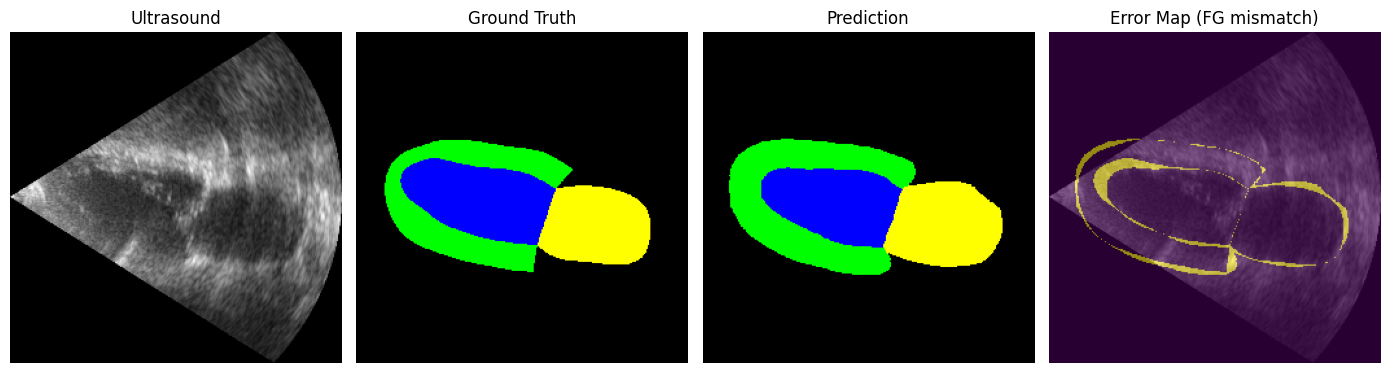

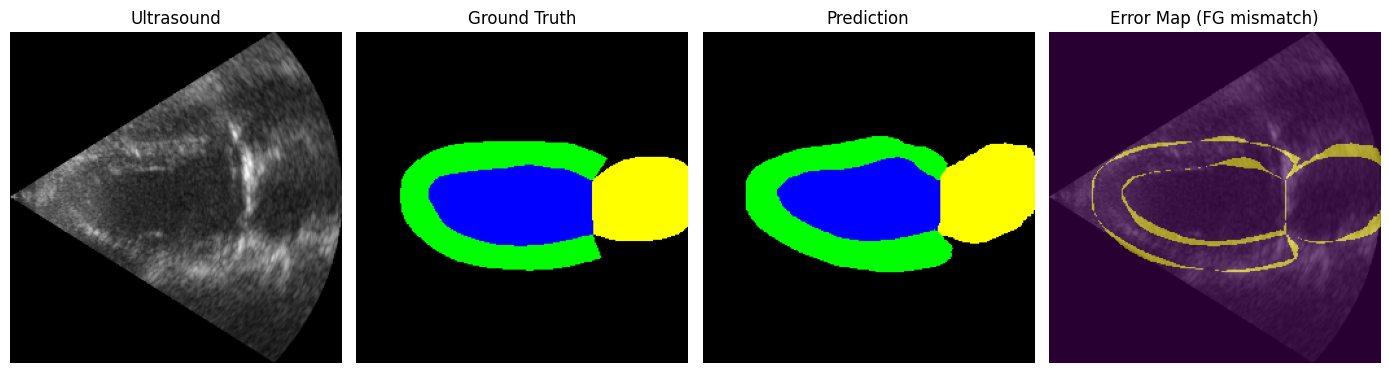

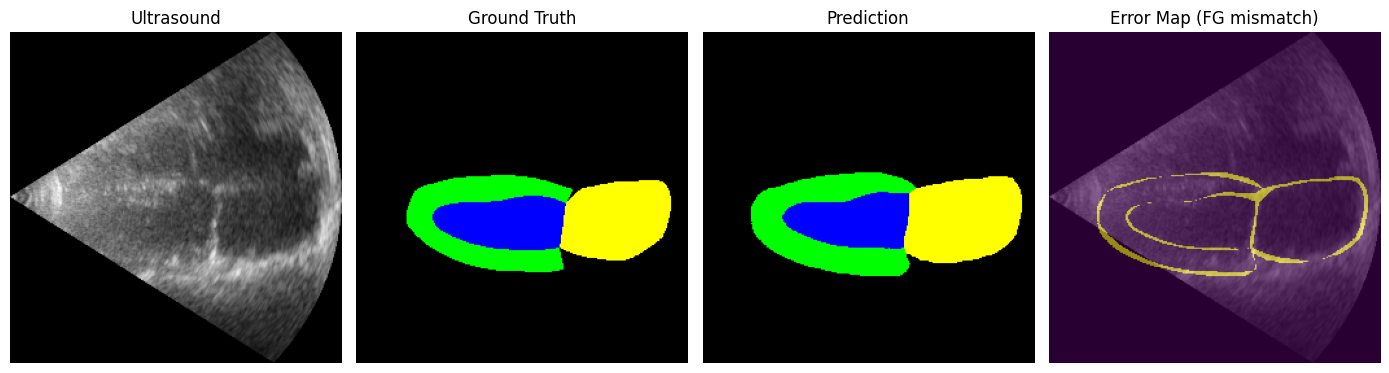

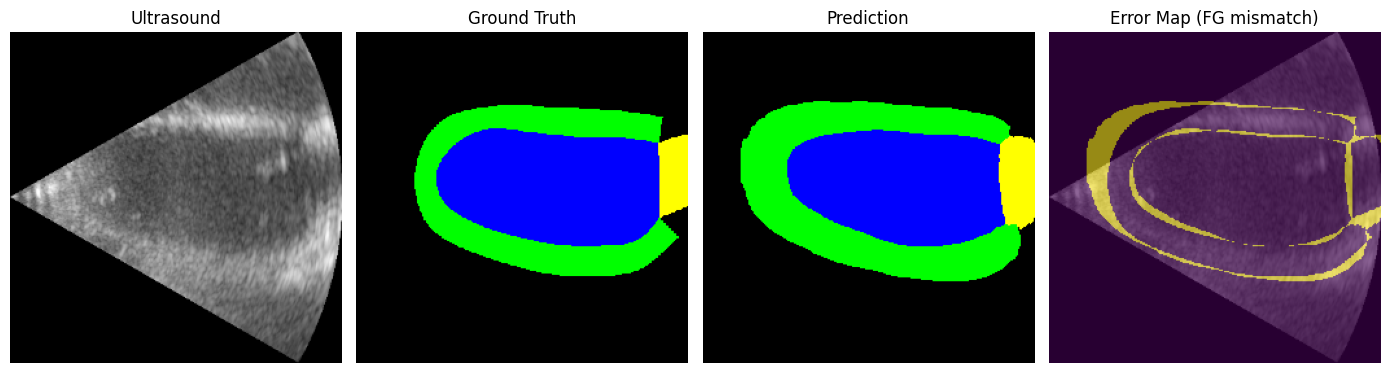

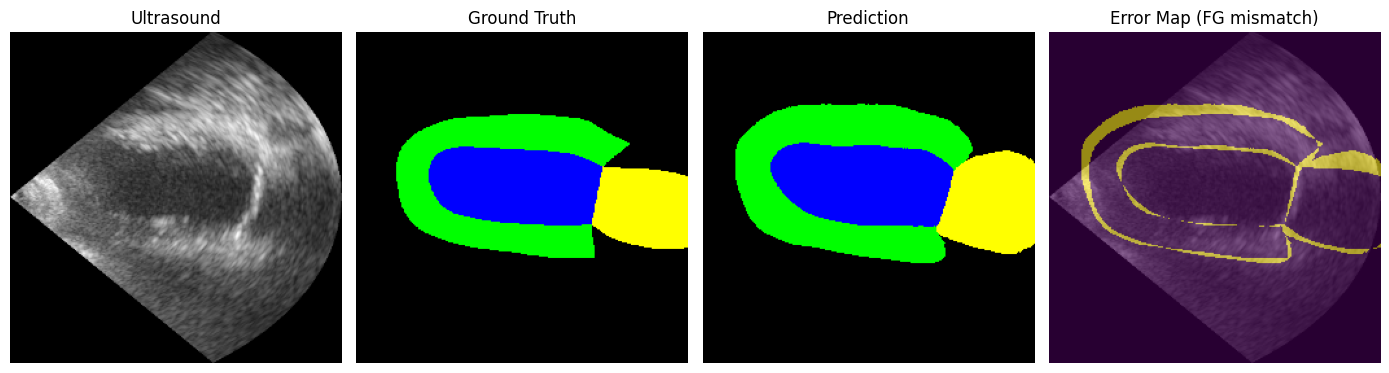

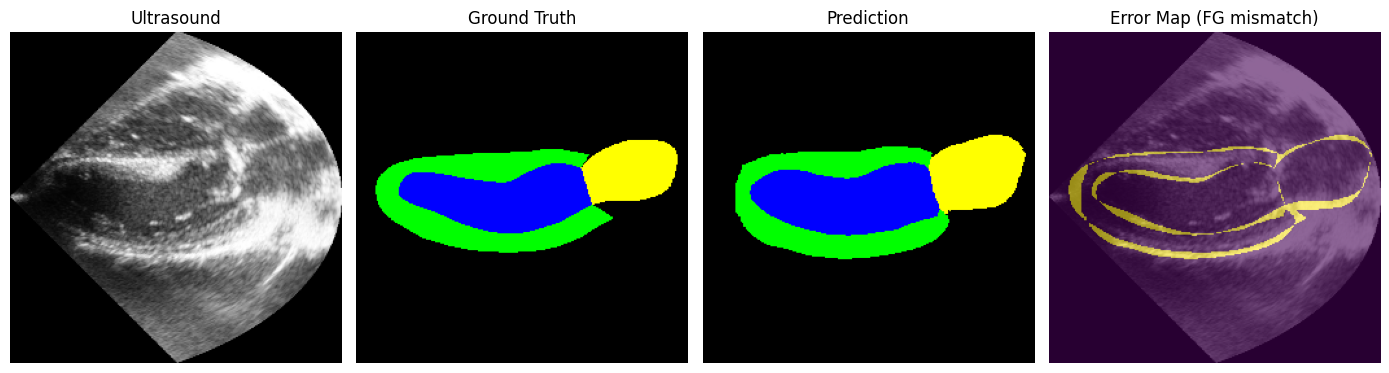

In [55]:
show_prediction_results(m3, val_loader, num_samples=6)

In [59]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch

def show_prediction_contours(model, loader, num_samples=6):

    model.eval()
    shown = 0

    with torch.no_grad():
        for x, y in loader:

            x = x.to(device)
            logits = model(x)
            preds = torch.argmax(logits, dim=1).cpu().numpy()

            imgs = x.cpu().numpy()
            gts = y.cpu().numpy()

            for i in range(x.shape[0]):

                img = imgs[i,0]
                img = (img * 0.5) + 0.5
                img = np.clip(img, 0, 1)

                gt = gts[i]
                pred = preds[i]

                plt.figure(figsize=(6,6))
                plt.imshow(img, cmap="gray")

                # =====================
                # LEFT VENTRICLE (LV)
                # =====================
                gt_lv = (gt == 1).astype(np.uint8)
                pr_lv = (pred == 1).astype(np.uint8)

                plt.contour(gt_lv, colors="blue", linewidths=2)                     # GT
                plt.contour(pr_lv, colors="cyan", linestyles="dashed", linewidths=2) # Prediction


                # =====================
                # MYOCARDIUM (MYO)
                # =====================
                gt_myo = (gt == 2).astype(np.uint8)
                pr_myo = (pred == 2).astype(np.uint8)

                plt.contour(gt_myo, colors="green", linewidths=2)
                plt.contour(pr_myo, colors="lime", linestyles="dashed", linewidths=2)


                # =====================
                # LEFT ATRIUM (LA)
                # =====================
                gt_la = (gt == 3).astype(np.uint8)
                pr_la = (pred == 3).astype(np.uint8)

                plt.contour(gt_la, colors="yellow", linewidths=2)
                plt.contour(pr_la, colors="orange", linestyles="dashed", linewidths=2)


                # =====================
                # LEGEND
                # =====================
                from matplotlib.lines import Line2D

                legend_elements = [

                    Line2D([0], [0], color='blue', lw=2, label='LV Ground Truth'),
                    Line2D([0], [0], color='cyan', lw=2, linestyle='--', label='LV Prediction'),

                    Line2D([0], [0], color='green', lw=2, label='MYO Ground Truth'),
                    Line2D([0], [0], color='lime', lw=2, linestyle='--', label='MYO Prediction'),

                    Line2D([0], [0], color='yellow', lw=2, label='LA Ground Truth'),
                    Line2D([0], [0], color='orange', lw=2, linestyle='--', label='LA Prediction'),
                ]

                plt.legend(handles=legend_elements, loc="upper right")

                plt.title("Ultrasound with Segmentation Contours")

                plt.axis("off")
                plt.show()

                shown += 1
                if shown >= num_samples:
                    return

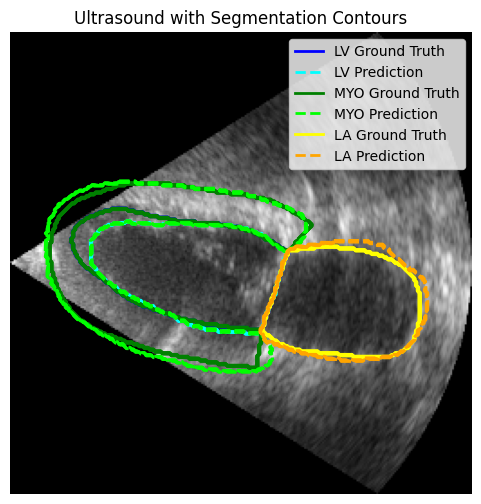

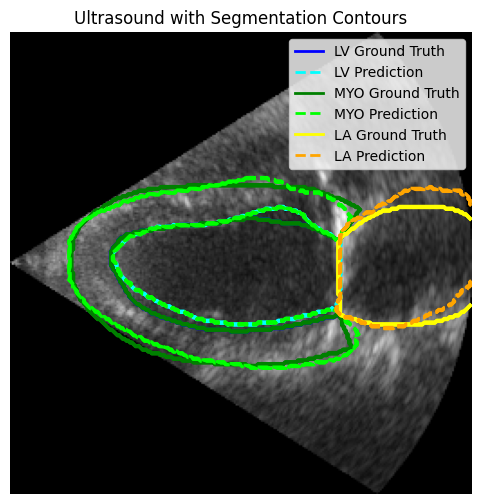

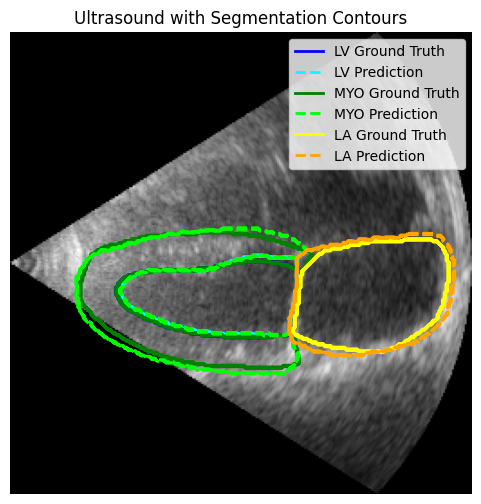

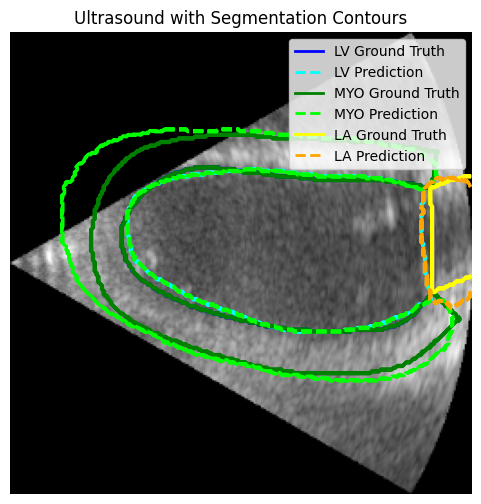

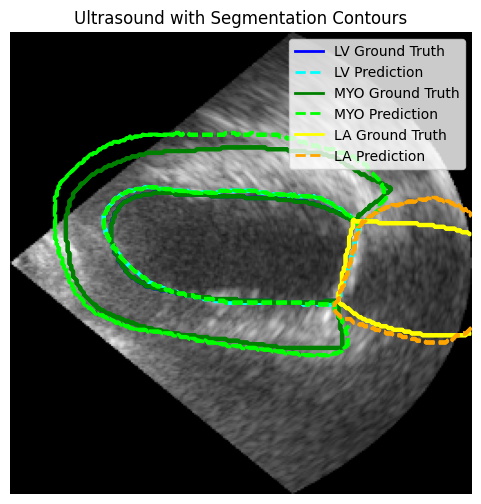

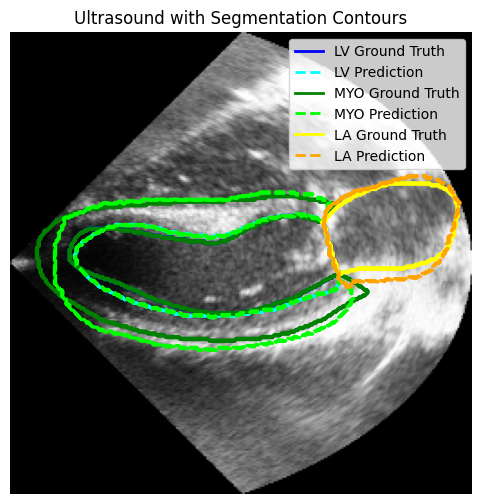

In [60]:
show_prediction_contours(m3, val_loader, num_samples=6)

In [61]:
import pandas as pd
import numpy as np

# ---- Load your saved results (change filenames only if yours are different) ----
w_nf = pd.read_csv("results_weighted_no_focal.csv", index_col=0)
w_f  = pd.read_csv("results_weighted_focal.csv", index_col=0)
b_nf = pd.read_csv("results_balanced_no_focal.csv", index_col=0)
b_f  = pd.read_csv("results_balanced_focal.csv", index_col=0)

def ensure_means(df):
    # If Mean_Dice/Mean_HD95 not present, compute them
    if "Mean_Dice" not in df.columns:
        df["Mean_Dice"] = df[["Dice_LV","Dice_MYO","Dice_LA"]].mean(axis=1)
    if "Mean_HD95" not in df.columns:
        df["Mean_HD95"] = df[["HD95_LV","HD95_MYO","HD95_LA"]].mean(axis=1)
    return df

w_nf = ensure_means(w_nf)
w_f  = ensure_means(w_f)
b_nf = ensure_means(b_nf)
b_f  = ensure_means(b_f)

# ---- Combine to a single comparison table ----
all_models = pd.concat([
    w_nf.assign(Setting="Weighted + NonFocal"),
    w_f.assign(Setting="Weighted + Focal"),
    b_nf.assign(Setting="Balanced + NonFocal"),
    b_f.assign(Setting="Balanced + Focal"),
], axis=0)

# Create a unique label per row (Setting | ModelName)
all_models["Label"] = all_models["Setting"] + " | " + all_models.index.astype(str)

# Keep only the columns we need for plotting/reporting
all_models_plot = all_models[["Label", "Setting", "Mean_Dice", "Mean_HD95",
                              "Dice_LV","Dice_MYO","Dice_LA"]].copy()

# Sort by Mean Dice (best to worst)
all_models_plot = all_models_plot.sort_values("Mean_Dice", ascending=False).reset_index(drop=True)

print("All models combined:", all_models_plot.shape[0], "rows")
display(all_models_plot.head(10))

All models combined: 20 rows


,Label,Setting,Mean_Dice,Mean_HD95,Dice_LV,Dice_MYO,Dice_LA
0,Balanced + NonFocal | Paper3_UNet_CE+Dice,Balanced + NonFocal,0.872700,8.371158,0.919684,0.835167,0.863247
1,Weighted + NonFocal | Paper1_UNet,Weighted + NonFocal,0.872143,9.022856,0.927036,0.833851,0.855543
2,Balanced + NonFocal | Paper5_UNet_Baseline,Balanced + NonFocal,0.870307,8.436408,0.919605,0.825496,0.865820
3,Balanced + Focal | Paper4_ResUNet_Focal,Balanced + Focal,0.863284,9.278114,0.919021,0.828657,0.842175
4,Weighted + NonFocal | Paper4_ResUNet,Weighted + NonFocal,0.861536,9.572370,0.911271,0.826787,0.846550
5,Weighted + Focal | Paper2_DeepLabV3_Focal,Weighted + Focal,0.856465,9.023268,0.898901,0.815037,0.855458
6,Balanced + NonFocal | Paper1_UNet,Balanced + NonFocal,0.855609,9.688250,0.918228,0.804535,0.844065
7,Balanced + NonFocal | Paper2_DeepLabV3,Balanced + NonFocal,0.853863,9.355660,0.906351,0.792074,0.863163
8,Balanced + Focal | Paper5_UNet_Baseline_Focal,Balanced + Focal,0.850411,9.937156,0.887146,0.825946,0.838142
9,Balanced + NonFocal | Paper4_ResUNet,Balanced + NonFocal,0.848265,9.796821,0.909038,0.820102,0.815654


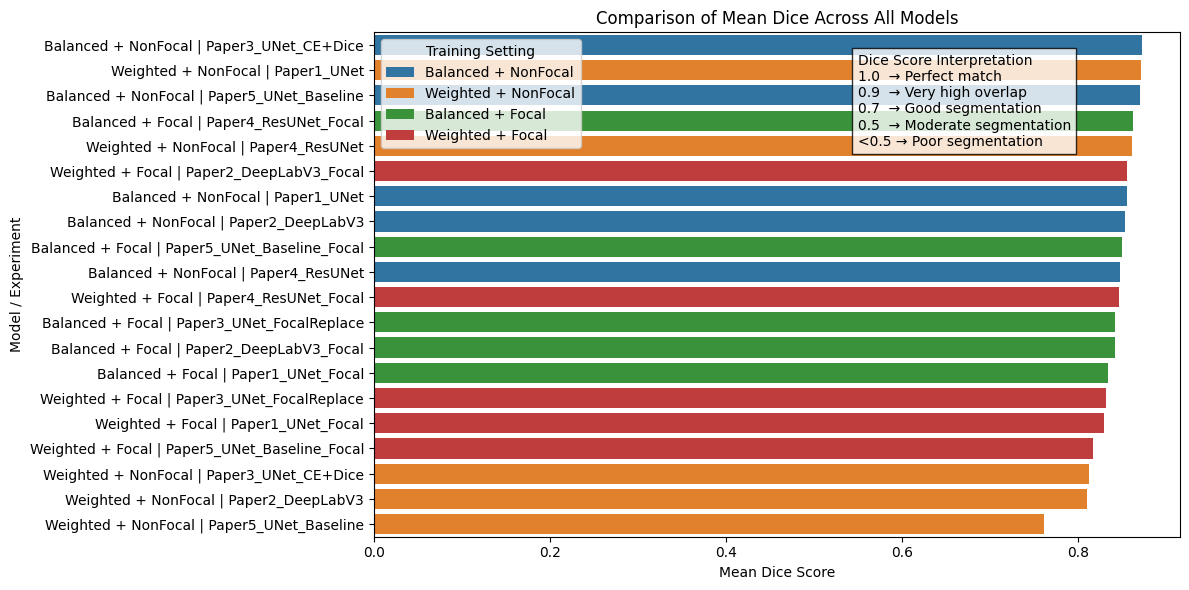

In [64]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))

sns.barplot(
    data=all_models_plot,
    x="Mean_Dice",
    y="Label",
    hue="Setting",
    dodge=False
)

plt.xlabel("Mean Dice Score")
plt.ylabel("Model / Experiment")
plt.title("Comparison of Mean Dice Across All Models")

plt.legend(title="Training Setting")

# Add Dice interpretation text box
dice_text = (
    "Dice Score Interpretation\n"
    "1.0  → Perfect match\n"
    "0.9  → Very high overlap\n"
    "0.7  → Good segmentation\n"
    "0.5  → Moderate segmentation\n"
    "<0.5 → Poor segmentation"
)

plt.text(
    0.55, 4,
    dice_text,
    fontsize=10,
    bbox=dict(facecolor='white', alpha=0.8)
)

plt.tight_layout()
plt.show()

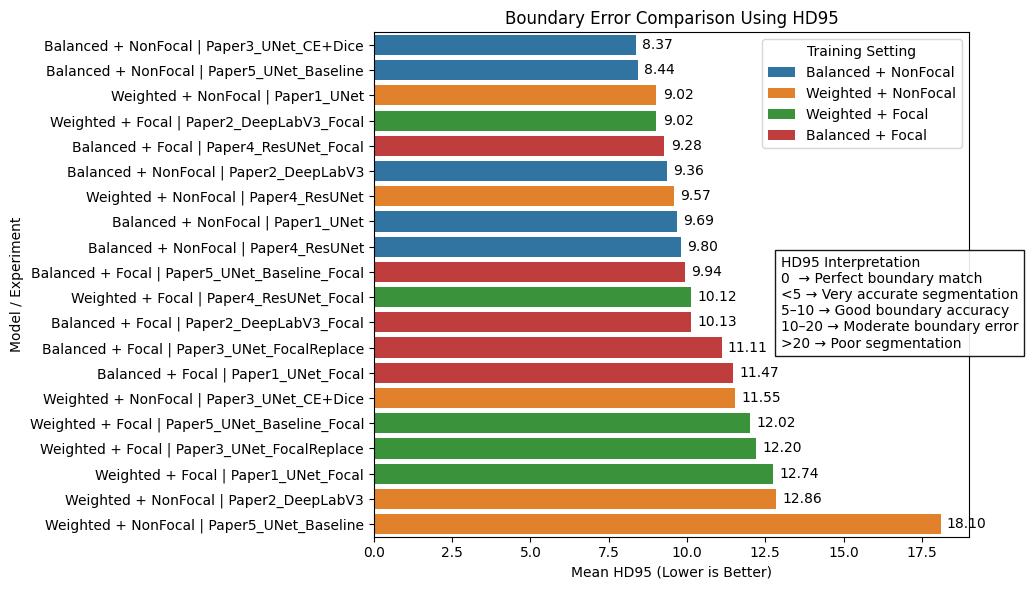

In [68]:
import matplotlib.pyplot as plt
import seaborn as sns

hd_df = all_models_plot.sort_values("Mean_HD95", ascending=True)

plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=hd_df,
    x="Mean_HD95",
    y="Label",
    hue="Setting",
    dodge=False
)

plt.xlabel("Mean HD95 (Lower is Better)")
plt.ylabel("Model / Experiment")
plt.title("Boundary Error Comparison Using HD95")

plt.legend(title="Training Setting")

# Add value labels
for i, v in enumerate(hd_df["Mean_HD95"]):
    ax.text(v + 0.2, i, f"{v:.2f}", va='center')

# Interpretation box
interpretation_text = (
    "HD95 Interpretation\n"
    "0  → Perfect boundary match\n"
    "<5 → Very accurate segmentation\n"
    "5–10 → Good boundary accuracy\n"
    "10–20 → Moderate boundary error\n"
    ">20 → Poor segmentation"
)

plt.text(
    13,
    len(hd_df)*0.6,
    interpretation_text,
    fontsize=10,
    bbox=dict(facecolor="white", alpha=0.9)
)

plt.tight_layout()
plt.show()